In [1]:
import numpy as np
from rpforest import RPForest
from scipy.io import loadmat
from tqdm import tqdm
from matplotlib import pyplot as plt

In [2]:
def get_mf_dino2():
    data = np.zeros((0, 384), dtype=np.float32)

    # Load Dino2
    for i in range(100):
        fp = loadmat(f"/Volumes/Data/mf_dino2/{i}.mat")['features']
        fp /= np.linalg.norm(fp, axis=1, keepdims=True)
        data = np.vstack((data, fp))
        
    data = np.ascontiguousarray(data, dtype=np.float32)
    return data

data = get_mf_dino2()

In [3]:
print(data.shape)

(1000000, 384)


In [4]:
x = RPForest(leaf_size=2000, no_trees=10)
x.fit(data)

In [5]:
xx = 0

for i in x.get_leaf_nodes():
    print(i)
    
    xx += 1
    
    if xx == 10:
        break

('0:000000000', [819, 1006, 2088, 4237, 4367, 5215, 5659, 7328, 7686, 7813, 8361, 9313, 9510, 11346, 11596, 12439, 12579, 12835, 13178, 13483, 14221, 14597, 14648, 14990, 16176, 17350, 17669, 17814, 18454, 18527, 18539, 20150, 20174, 20525, 21372, 21915, 22018, 22036, 22374, 22575, 22681, 23069, 23139, 23351, 24743, 24822, 24878, 25983, 26035, 26974, 27317, 27660, 28126, 32106, 32169, 32538, 32617, 34192, 34328, 34657, 34711, 34730, 34944, 35668, 36078, 36746, 36765, 36769, 37652, 37804, 38434, 38623, 39418, 41063, 41075, 41293, 42861, 43017, 44105, 44332, 45377, 45967, 46202, 47054, 47251, 48248, 49701, 50269, 50466, 50861, 51123, 53394, 53650, 53766, 53940, 55318, 55376, 56153, 56155, 56218, 56834, 57347, 57471, 57646, 57667, 57732, 58555, 59551, 59745, 60657, 61269, 61577, 61841, 61966, 62246, 62471, 62592, 62621, 63299, 63920, 64054, 65321, 65690, 65859, 66113, 66225, 67128, 68032, 68254, 68859, 69034, 69461, 69626, 70290, 70730, 71418, 72170, 72290, 73022, 73061, 73182, 73397, 734

In [6]:
j = 0

results = [[] for i in range(1_000_000)]

for leaf in tqdm(x.get_leaf_nodes()):
    
    ids = np.array(leaf[1])
    
    dot_prods = data[ids] @ data[ids].T    
    sorted_idxs = np.flip(np.argsort(dot_prods, axis=1), axis=1)
    
    indexes = sorted_idxs[:, 0]
    top_k = sorted_idxs[:, 1:16]
        
    global_indexes = ids[indexes]        
    global_nns = ids[top_k]
    
    # Need to put the top k in each index, but convert back to global IDs
    for i in range(len(indexes)):
        results[global_indexes[i]].extend(global_nns[i])

5120it [17:02,  5.01it/s]


In [7]:
for i in range(1_000_000):
    results[i] = list(set(results[i]))

In [8]:
print(results[0])

[746502, 258065, 608274, 672796, 721442, 794148, 398897, 858162, 451125, 66108, 584769, 570946, 703556, 570950, 383046, 452166, 207433, 581711, 371283, 582739, 459866, 462427, 935515, 624221, 931934, 957022, 564831, 223329, 902242, 448102, 783977, 970346, 93803, 462441, 135797, 184442, 617083, 931966, 859264, 513158, 510094, 29328, 361108, 302747, 917154, 430243, 586405, 832165, 841896, 812213, 999606, 868538, 55486, 329408, 989379, 47315, 431325, 97502, 278240, 598757, 731368, 54505, 385773, 725749, 283893, 339701, 910072, 827645, 339712, 359680, 570114, 321017, 587544, 244510, 33058, 477990, 609065, 558377, 80693, 358711, 970561, 697671, 544584, 176457, 271693, 778064, 324433, 723795, 694099, 677720, 580451, 83812, 535910, 494951, 444777, 585585, 72050, 39795, 76147, 601461, 290677, 549253, 615813, 314761, 39819, 767371, 89490, 575892, 775574, 753558, 339359, 44960, 772513, 958885, 486832, 868786, 628149, 550326, 471990, 700855, 741817, 661440, 527813, 854470, 504782, 767442, 131029,

In [9]:
dists = [[] for i in range(1_000_000)]

for id in tqdm(range(len(dists))):
    nns = results[id]
    
    for nn in nns:
        dot_prod = np.dot(data[id], data[nn])
        dists[id].append(dot_prod)


100%|██████████| 1000000/1000000 [03:07<00:00, 5331.03it/s]


In [10]:
argsorted_dist_rows = [np.flip(np.argsort(x)) for x in dists]
print(argsorted_dist_rows[0])

[ 95  93  19 126   3   6   4  15 115  39  94  16  46  22 107 131  37  65
  47 127 108  28  26  43 116  82  89  20  99  41 122 119  45  87  14  96
  51 130 132  85 105 111 117   9  58   0 133 104 128 110  81  72 103  11
   2  73  88 123  90 136 129   5 120  53  29  63  68  27  24  98  55  33
  75 113  76 102  56  10  92  91  25  60   1  57 109 112 121  30  31  50
  67  12 125   8  77  18  36  32  21  78  49  48  83  59  70 124  69  40
  66 134  62  52  23  61  79 114   7  54  80  64  74  38  42  44 100  71
  17 101 135 106  86 118  84  35  13  34  97]


In [11]:
nn15_seed = [[] for i in range(1_000_000)]

for i in tqdm(range(len(results))):
    nn15_seed[i] = np.array(results[i])[argsorted_dist_rows[i][:15]]

100%|██████████| 1000000/1000000 [00:06<00:00, 154803.61it/s]


In [12]:
len_overlaps = []
for id in np.random.choice(1_000_000, size=1000):
    dot_sims = np.dot(data, data[id])
    ord = np.flip(np.argsort(dot_sims))[1:16]
    overlap = np.intersect1d(ord, nn15_seed[id])
    len_overlaps.append(len(overlap))

Text(0, 0.5, 'Frequency')

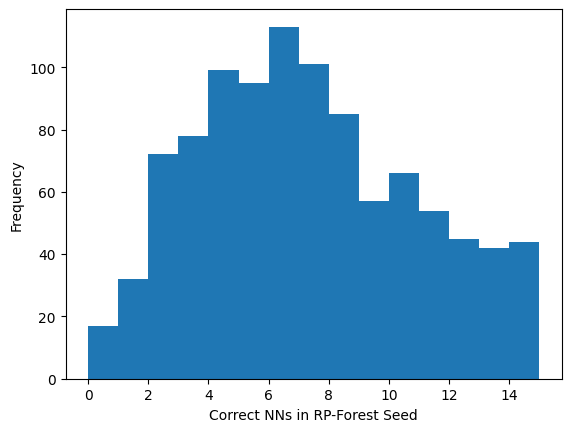

In [13]:
plt.hist(len_overlaps, bins=15)

plt.xlabel("Correct NNs in RP-Forest Seed")
plt.ylabel("Frequency")

In [14]:
print(np.mean(len_overlaps))

6.836


In [15]:
# 15 @ 100
len_overlaps_at_100 = []
for id in np.random.choice(1_000_000, size=1000):
    dot_sims = np.dot(data, data[id])
    ord = np.flip(np.argsort(dot_sims))[1:101]
    overlap = np.intersect1d(ord, nn15_seed[id])
    len_overlaps_at_100.append(len(overlap))
    

Text(0, 0.5, 'Frequency')

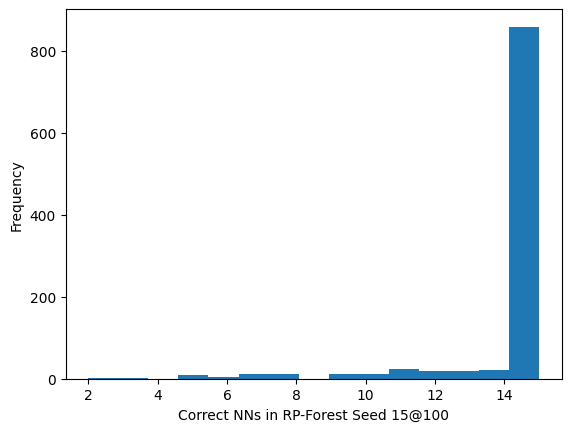

In [16]:
plt.hist(len_overlaps_at_100, bins=15)

plt.xlabel("Correct NNs in RP-Forest Seed 15@100")
plt.ylabel("Frequency")

In [ ]:
print(np.mean(len_overlaps_at_100) / 15)

14.365
